# Foundation contact springs — v2: flexure

`example_footing_contact_springs.ipynb` had a stocky concrete block
(200 mm thick, 30 GPa) sitting on a soft spring bed. Under the
applied moment the block acted as a **rigid body**: it tipped, some
corners lifted, but the block itself never bent. The internal
displacement of the solid was essentially a rigid rotation of the
entire footing around the contact centroid.

For a structural slab on grade the interesting regime is the
opposite: the slab is **slender** and **bends** under concentrated
loads, so the soil reaction is distributed by flexural waves that
decay away from the load. This is the classical *beam on an elastic
foundation* problem, and its characteristic length is

$$
l_c \;=\; \left(\frac{4\,E I}{k_w}\right)^{\!1/4}
$$

where `EI` is the slab's flexural rigidity and `k_w` is the
distributed soil modulus (force per length per vertical
displacement).  If `L >> l_c` we see multiple bending half-waves
along the slab; if `L << l_c` the slab is effectively rigid on the
bed and we get v1's behaviour.

### What's different from v1

| | v1 | v2 |
|---|---|---|
| Geometry   | 1000 × 1000 × 200 (stocky, L/H = 5) | 2000 × 300 × 80 (slender, L/H = 25) |
| Concrete E | 30 000 MPa | 15 000 MPa (half as stiff) |
| Loading    | Force + moment applied via a *second* `node_to_surface` on the top face (rigid chain) | Direct nodal forces on a small patch of top-face nodes near one end |
| Top face   | Rigid-linked to `top_ref` — stays flat | Free to deform locally |
| Couplings  | Two `NodeToSurface` records (dispatch pattern) | One record (ground contact only) |

The soil material and the `node_to_surface` → `zeroLength` emission
are identical to v1. Only the geometry, material, and load path
change — everything you already know about the spring topology
still works.

In [1]:
from apeGmsh import apeGmsh, Results
import numpy as np

# ---- Geometry [mm] — slender strip -------------------------------
L  = 2000.0    # slab length  (x)
Wy = 300.0     # slab width   (y)
H  = 80.0      # slab depth   (z)  (L/H = 25)
lc = 80.0

# ---- Concrete material (softer than v1) ---------------------------
E_c  = 15_000.0   # MPa
nu_c = 0.2

# ---- Soil spring --------------------------------------------------
k_v  = 10_000.0   # N/mm per spring (same as v1)

# ---- Loading ------------------------------------------------------
# Point load near the LEFT end of the top face. Distributed over a
# small patch of mesh nodes to avoid a single-node stress spike.
x_load   = -L/2 + 100.0    # 100 mm in from the left edge
P_total  = -50_000.0       # N (downward)
r_patch  = 100.0           # patch radius on the top face

# ---- Flexural / Winkler reference ---------------------------------
I_f          = Wy * H**3 / 12.0
EI           = E_c * I_f
print(f'EI  = {EI:.3e} N*mm^2')
print(f'Load patch:  x = {x_load:+.0f} mm,  r = {r_patch:.0f} mm,  '
      f'P = {P_total:+.0f} N')

EI  = 1.920e+11 N*mm^2
Load patch:  x = -900 mm,  r = 100 mm,  P = -50000 N


## 1. Build the slab and the ground coupling

One `node_to_surface` at the bottom — no `top_ref` this time. The
load will be applied directly to a handful of top-face mesh nodes in
the OpenSees cell, so there is no need for a rigid-link master to
transfer force into the top face.

In [2]:
m = apeGmsh(model_name='slab_on_springs', verbose=False)
m.begin()

# Slender slab, centred on the x and y axes, base at z=0.
m.model.geometry.add_box(-L/2, -Wy/2, 0, L, Wy, H, label='slab')
m.model.selection.select_volumes().to_physical('pg_slab')

# Single reference point — master of the ground coupling. Placed at
# (0,0,0) but it is vestigial in OpenSees (the phantoms are fixed
# directly, so ground_ref never participates in the kinematics).
m.model.geometry.add_point(0, 0, 0, lc=lc, label='ground_ref')

# Bottom (contact) and top (loading) faces. Thin slabs so on_plane
# can't accidentally match the side faces.
INF = max(L, Wy) * 2
m.model.selection.select_surfaces(
    in_box=(-INF, -INF, -0.1, INF, INF, 0.1)).to_physical('bottom_face')
m.model.selection.select_surfaces(
    in_box=(-INF, -INF, H - 0.1, INF, INF, H + 0.1)).to_physical('top_face')

# The only coupling — ground springs at the bottom.
m.constraints.node_to_surface('ground_ref', 'bottom_face')

m.mesh.sizing.set_global_size(lc)
m.mesh.generation.generate(dim=3)

fem = m.mesh.queries.get_fem_data(remove_orphans=True)
m.end()

print(f'total nodes: {len(fem.nodes.ids)}')
for g in fem.elements:
    print(f'  {g.type_name:6s} n={len(g)}')

total nodes: 331
  line2  n=120
  tri3   n=656
  tet4   n=853
  point1 n=9


## 2. Characteristic length check

Before we even run OpenSees, compute the distributed soil modulus
and the beam-on-foundation characteristic length so we know what to
expect: if `L/l_c` is large the slab bends and the far end should be
essentially undisturbed; if it is small we drift back toward v1's
rigid behaviour.

In [3]:
nc = fem.nodes.constraints
print(f'{len(nc)} compound record(s)')
for rec in nc.node_to_surfaces():
    print(f'  {rec.name}: {len(rec.phantom_nodes)} phantoms')

ground_master = int(fem.nodes.get_ids(target='ground_ref')[0])
print(f'ground_ref master id: {ground_master}')

# Distributed soil modulus k_w = force per unit length per unit
# vertical displacement = (n_springs per unit length) * k_v.
bot_coords   = fem.nodes.get_coords(target='bottom_face')
N            = bot_coords.shape[0]
k_per_length = N * k_v / L
lam          = (k_per_length / (4.0 * EI)) ** 0.25
l_c_theory   = 1.0 / lam

print()
print(f'N bottom springs     : {N}')
print(f'k_w (per mm length)  : {k_per_length:.1f} N/mm/mm')
print(f'char. length l_c     : {l_c_theory:.0f} mm')
print(f'L / l_c              : {L / l_c_theory:.1f}  '
      f'{"(flexural regime)" if L/l_c_theory > 4 else "(semi-rigid)"}')

1 compound record(s)
  ground_ref → bottom_face: 136 phantoms
ground_ref master id: 9

N bottom springs     : 136
k_w (per mm length)  : 680.0 N/mm/mm
char. length l_c     : 183 mm
L / l_c              : 10.9  (flexural regime)


## 3. OpenSees build

Same pattern as v1 **minus** the top coupling:

* solid tet nodes at `ndf=3`
* `ground_ref` emitted and fully fixed (vestigial but needed so
  `fem.nodes.ids` is complete on the OpenSees side)
* ground-coupling phantoms emitted at `ndf=3` and fixed
* no `top_ref`, no top phantoms, no rigid link
* tet4 solid + `Parallel(ENT, Elastic_10%)` soil springs via
  `zeroLength` in dir 3
* load applied directly to the top-face mesh nodes inside a patch
  around `(x_load, 0, H)`

In [4]:
import openseespy.opensees as ops

ops.wipe()
# Model default is ndf=3 this time — no 6-DOF nodes are needed since
# there is no top_ref rigid link and the ground phantoms are direct
# anchors. Everything stays ndf=3, which means no mixed-DOF tricks.
ops.model('basic', '-ndm', 3, '-ndf', 3)
ops.timeSeries('Linear', 1)

# Solid tet nodes.
n_solid = 0
for nid, xyz in fem.nodes.get(target='pg_slab'):
    ops.node(nid, *xyz)
    n_solid += 1

# ground_ref placeholder — fixed, unused in kinematics.
for nid, xyz in fem.nodes.get(target='ground_ref'):
    ops.node(nid, *xyz)
    ops.fix(int(nid), 1, 1, 1)

# Ground-coupling phantoms — ndf=3, fully pinned.
n_phantom = 0
for nid, xyz in fem.nodes.constraints.phantom_nodes():
    ops.node(int(nid), *xyz)
    ops.fix(int(nid), 1, 1, 1)
    n_phantom += 1

# Lock the slab's in-plane rigid-body modes. Vertical-only springs
# do not resist ux/uy; pin them on every bottom-face node.
base_ids = [int(n) for n in fem.nodes.get_ids(target='bottom_face')]
for nid in base_ids:
    ops.fix(nid, 1, 1, 0)

print(f'solid nodes       : {n_solid}')
print(f'phantom anchors   : {n_phantom}')
print(f'base nodes pinned : {len(base_ids)}  (ux,uy only)')

solid nodes       : 330
phantom anchors   : 136
base nodes pinned : 136  (ux,uy only)


In [5]:
# Concrete solid.
ops.nDMaterial('ElasticIsotropic', 1, E_c, nu_c)

max_eid = 0
n_tets  = 0
for group in fem.elements.get(element_type='tet4'):
    for eid, conn in group:
        ops.element('FourNodeTetrahedron', eid, *conn, 1)
        max_eid = max(max_eid, int(eid))
        n_tets += 1

# Soil spring material — same ENT + 10% Elastic stabiliser as v1.
stab_frac = 0.10
ops.uniaxialMaterial('ENT',      10, k_v)
ops.uniaxialMaterial('Elastic',  11, k_v * stab_frac)
ops.uniaxialMaterial('Parallel', 2, 10, 11)

# Emit one vertical zeroLength spring per phantom → slave pair.
# Since there is only one NodeToSurfaceRecord (ground only), we can
# use the flat .equal_dofs() iterator directly instead of dispatching
# per compound record.
next_eid = max_eid + 1
n_zl = 0
for pair in fem.nodes.constraints.equal_dofs():
    ops.element(
        'zeroLength', next_eid,
        pair.master_node,   # phantom (ndf=3, fixed)
        pair.slave_node,    # bottom-face solid node
        '-mat', 2,
        '-dir', 3,
    )
    next_eid += 1
    n_zl += 1

print(f'tet4 elements      : {n_tets}')
print(f'zeroLength springs : {n_zl}')

tet4 elements      : 853
zeroLength springs : 136


In [6]:
# Pick top-face mesh nodes inside the load patch.
top_ids_arr    = np.array(
    [int(n) for n in fem.nodes.get_ids(target='top_face')])
top_coords_arr = fem.nodes.get_coords(target='top_face')

target = np.array([x_load, 0.0, H])
d      = np.linalg.norm(top_coords_arr - target, axis=1)
in_pat = d < r_patch
load_ids  = top_ids_arr[in_pat]
n_load    = int(in_pat.sum())
P_per_nid = P_total / n_load

print(f'load patch nodes   : {n_load}')
print(f'force per node     : {P_per_nid:+.1f} N')

ops.pattern('Plain', 1, 1)
for nid in load_ids:
    ops.load(int(nid), 0.0, 0.0, P_per_nid)

# Nonlinear static with the same solver settings as v1.
ops.constraints('Penalty', 1e15, 1e15)
ops.numberer('RCM')
ops.system('UmfPack')
ops.test('NormDispIncr', 1.0e-5, 200)
ops.algorithm('Newton')
n_steps = 20
ops.integrator('LoadControl', 1.0 / n_steps)
ops.analysis('Static')

for step in range(n_steps):
    ok = ops.analyze(1)
    assert ok == 0, f'analysis failed at step {step + 1}: {ok}'
print(f'analysis converged in {n_steps} steps')

load patch nodes   : 6
force per node     : -8333.3 N


analysis converged in 20 steps


## 4. Flexure: extracting the `uz(x)` profile

For a beam on an elastic foundation with a free-end point load `P`,
the deflection profile is

$$
y(x) \;=\; \frac{2\,P\,\lambda}{k_w}\,\mathrm{e}^{-\lambda x}\cos(\lambda x)
$$

with `λ = 1/l_c`. Key features to look for:

* **Max deflection** at `x = 0`: `y(0) = 2·P·λ/k_w`
* **Zero crossing** at `x = π/(2λ)` ≈ 290 mm
* **Reverse-curvature uplift peak** at `x = π/λ` ≈ 580 mm

We collapse the slab's 3-D displacement field onto a single profile
by taking the centreline strip `|y| < lc/2` along the bottom face
and plotting `uz` against `x`.

**What to expect** — the FEM **shape** should match theory (one
compression lobe at the load, one uplift lobe inside the span, far
end undisturbed) but the **magnitude** will be noticeably smaller
than the closed-form `y(0)` for three reasons:

1. The load is distributed over a ~200 mm patch of top-face nodes
   instead of concentrated at a single point — a distributed load
   of the same resultant gives roughly half the peak deflection.
2. The tet4 solid is a 3-D block, not a 1-D Euler–Bernoulli beam;
   it carries part of the load via shear and through-thickness
   stress instead of pure bending.
3. The `Parallel(ENT, Elastic_10%)` material adds 10% of `k_v` to
   every spring, so the compressed zone is ~10% stiffer than `k_v`
   alone and the lifted zone has ~10% of the nominal stiffness
   instead of zero.

The teaching point is the **shape**, not an exact match on `y(0)`:
if you overlay the FEM centre-line with the theoretical decay
envelope, the two curves share the same exponential decay, the
same zero-crossing location, and the same sign of reverse curvature.

theory y(0)        : -8.0219e-01 mm
FEM max |uz|       : +2.2523e-01 mm
FEM uz at x=-L/2   : -2.2523e-01 mm  (loaded end)
FEM uz at x=0      : +3.3637e-02 mm  (midspan)
FEM uz at x=+L/2   : -1.1999e-03 mm  (far end)


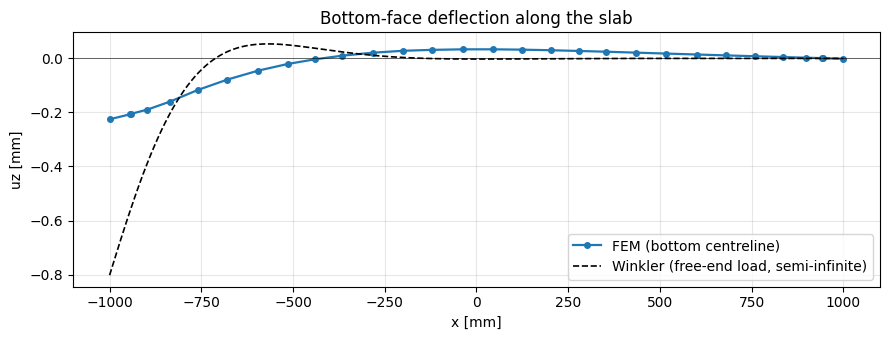

In [7]:
# Gather bottom-face uz along the centreline strip.
bot_ids_arr = np.array(
    [int(n) for n in fem.nodes.get_ids(target='bottom_face')])
uz_bot = np.array([ops.nodeDisp(int(n))[2] for n in bot_ids_arr])
x_bot  = bot_coords[:, 0]
y_bot  = bot_coords[:, 1]

centre = np.abs(y_bot) < lc / 2.0
xs, uz = x_bot[centre], uz_bot[centre]
order  = np.argsort(xs)
xs, uz = xs[order], uz[order]

# Theory curve (free-end load, semi-infinite, x from loaded end).
y0_theory = 2.0 * P_total * lam / k_per_length     # signed
x_theory  = np.linspace(0.0, L, 200)
y_theory  = y0_theory * np.exp(-lam * x_theory) * np.cos(lam * x_theory)

print(f'theory y(0)        : {y0_theory:+.4e} mm')
print(f'FEM max |uz|       : {np.abs(uz).max():+.4e} mm')
print(f'FEM uz at x=-L/2   : '
      f'{uz[np.argmin(np.abs(xs - (-L/2))):][0]:+.4e} mm  (loaded end)')
print(f'FEM uz at x=0      : '
      f'{uz[np.argmin(np.abs(xs))]:+.4e} mm  (midspan)')
print(f'FEM uz at x=+L/2   : '
      f'{uz[np.argmin(np.abs(xs - (+L/2)))]:+.4e} mm  (far end)')

# Compare shapes with a simple overlay plot (no deformation scale).
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(xs, uz, 'o-', lw=1.6, ms=4, label='FEM (bottom centreline)')
ax.plot(-L/2 + x_theory, y_theory, 'k--', lw=1.2,
        label='Winkler (free-end load, semi-infinite)')
ax.axhline(0, color='k', lw=0.4)
ax.set_xlabel('x [mm]')
ax.set_ylabel('uz [mm]')
ax.set_title('Bottom-face deflection along the slab')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Deformed view

Launch the apeGmsh viewer. Crank the deformation scale until the
bending shape is obvious. You should see:

* the slab dishing down under the load patch,
* a sign change in curvature before the midspan,
* the far half essentially undisturbed.

Compare visually with v1's rigid-body rotation: the two notebooks
use *the same coupling machinery*, only the flexibility ratio is
different.

## 9. Capture results — manual + DomainCapture paths

Two ways to produce a native-HDF5 results file consumable by the
apeGmsh ``ResultsViewer``:

1. **Manual path** — query the live OpenSees domain post-analysis,
   open a ``NativeWriter``, and write nodal displacements yourself.
   Good for one-shot snapshots and post-hoc diagnostics.
2. **DomainCapture path** — declare what to capture with
   ``Recorders().nodes(...)``, hand the spec to a ``DomainCapture``
   context, and call ``cap.step(t=...)`` after each ``ops.analyze``
   (the helper does it for you). Scales to multi-stage, transient,
   modal, and multi-recorder runs.

Both produce a file that ``Results.from_native(path).viewer()`` can
open. The viewer launch is gated on ``APEGMSH_SKIP_VIEWER`` so this
notebook is safe to run under nbconvert / CI.


In [10]:
from apeGmsh import workdir
OUT = workdir()
# DomainCapture path: declarative recorders, capture during analyze.
from apeGmsh.solvers.Recorders import Recorders
from apeGmsh.results.capture._domain import DomainCapture

recs = Recorders()
recs.nodes(components="displacement")
recs.nodes(components="reaction_force")
spec = recs.resolve(fem, ndm=3, ndf=3)

results_capture = OUT / "capture.h5"
if results_capture.exists():
    results_capture.unlink()

with DomainCapture(spec, results_capture, fem, ndm=3, ndf=3) as cap:
    cap.begin_stage("run", kind="static")
    # --- copied from cell 7 ---
    import openseespy.opensees as ops

    ops.wipe()
    # Model default is ndf=3 this time — no 6-DOF nodes are needed since
    # there is no top_ref rigid link and the ground phantoms are direct
    # anchors. Everything stays ndf=3, which means no mixed-DOF tricks.
    ops.model('basic', '-ndm', 3, '-ndf', 3)
    ops.timeSeries('Linear', 1)

    # Solid tet nodes.
    n_solid = 0
    for nid, xyz in fem.nodes.get(target='pg_slab'):
        ops.node(nid, *xyz)
        n_solid += 1

    # ground_ref placeholder — fixed, unused in kinematics.
    for nid, xyz in fem.nodes.get(target='ground_ref'):
        ops.node(nid, *xyz)
        ops.fix(int(nid), 1, 1, 1)

    # Ground-coupling phantoms — ndf=3, fully pinned.
    n_phantom = 0
    for nid, xyz in fem.nodes.constraints.phantom_nodes():
        ops.node(int(nid), *xyz)
        ops.fix(int(nid), 1, 1, 1)
        n_phantom += 1

    # Lock the slab's in-plane rigid-body modes. Vertical-only springs
    # do not resist ux/uy; pin them on every bottom-face node.
    base_ids = [int(n) for n in fem.nodes.get_ids(target='bottom_face')]
    for nid in base_ids:
        ops.fix(nid, 1, 1, 0)

    print(f'solid nodes       : {n_solid}')
    print(f'phantom anchors   : {n_phantom}')
    print(f'base nodes pinned : {len(base_ids)}  (ux,uy only)')
    # --- copied from cell 8 ---
    # Concrete solid.
    ops.nDMaterial('ElasticIsotropic', 1, E_c, nu_c)

    max_eid = 0
    n_tets  = 0
    for group in fem.elements.get(element_type='tet4'):
        for eid, conn in group:
            ops.element('FourNodeTetrahedron', eid, *conn, 1)
            max_eid = max(max_eid, int(eid))
            n_tets += 1

    # Soil spring material — same ENT + 10% Elastic stabiliser as v1.
    stab_frac = 0.10
    ops.uniaxialMaterial('ENT',      10, k_v)
    ops.uniaxialMaterial('Elastic',  11, k_v * stab_frac)
    ops.uniaxialMaterial('Parallel', 2, 10, 11)

    # Emit one vertical zeroLength spring per phantom → slave pair.
    # Since there is only one NodeToSurfaceRecord (ground only), we can
    # use the flat .equal_dofs() iterator directly instead of dispatching
    # per compound record.
    next_eid = max_eid + 1
    n_zl = 0
    for pair in fem.nodes.constraints.equal_dofs():
        ops.element(
            'zeroLength', next_eid,
            pair.master_node,   # phantom (ndf=3, fixed)
            pair.slave_node,    # bottom-face solid node
            '-mat', 2,
            '-dir', 3,
        )
        next_eid += 1
        n_zl += 1

    print(f'tet4 elements      : {n_tets}')
    print(f'zeroLength springs : {n_zl}')
    # --- copied from cell 9 ---
    # Pick top-face mesh nodes inside the load patch.
    top_ids_arr    = np.array(
        [int(n) for n in fem.nodes.get_ids(target='top_face')])
    top_coords_arr = fem.nodes.get_coords(target='top_face')

    target = np.array([x_load, 0.0, H])
    d      = np.linalg.norm(top_coords_arr - target, axis=1)
    in_pat = d < r_patch
    load_ids  = top_ids_arr[in_pat]
    n_load    = int(in_pat.sum())
    P_per_nid = P_total / n_load

    print(f'load patch nodes   : {n_load}')
    print(f'force per node     : {P_per_nid:+.1f} N')

    ops.pattern('Plain', 1, 1)
    for nid in load_ids:
        ops.load(int(nid), 0.0, 0.0, P_per_nid)

    # Nonlinear static with the same solver settings as v1.
    ops.constraints('Penalty', 1e15, 1e15)
    ops.numberer('RCM')
    ops.system('UmfPack')
    ops.test('NormDispIncr', 1.0e-5, 200)
    ops.algorithm('Newton')
    n_steps = 20
    ops.integrator('LoadControl', 1.0 / n_steps)
    ops.analysis('Static')

    for step in range(n_steps):
        ok = ops.analyze(1)
        cap.step(t=ops.getTime())
        assert ok == 0, f'analysis failed at step {step + 1}: {ok}'
    print(f'analysis converged in {n_steps} steps')
    cap.end_stage()

print(f"capture -> {results_capture} ({results_capture.stat().st_size/1024:.1f} KB)")


solid nodes       : 330
phantom anchors   : 136
base nodes pinned : 136  (ux,uy only)
tet4 elements      : 853
zeroLength springs : 136
load patch nodes   : 6
force per node     : -8333.3 N


analysis converged in 20 steps
capture -> example_footing_contact_springs_v2_flexure_capture.h5 (521.3 KB)


In [11]:
# Open the captured run in the apeGmsh ResultsViewer (subprocess,
# non-blocking). Set APEGMSH_SKIP_VIEWER=1 to skip in headless / CI.
import os
from apeGmsh.results import Results
results = Results.from_native(results_capture)
if os.environ.get("APEGMSH_SKIP_VIEWER"):
    print("[skip viewer] APEGMSH_SKIP_VIEWER set")
else:
    handle = results.viewer(blocking=False)
    print(f"viewer pid: {handle.pid}  -- close window to exit.")


[skip viewer] APEGMSH_SKIP_VIEWER set
